# Boston Housing - Pytorch Neural Network

## Admin

In [1]:
# import libraries 

# torch Libriaries 
import torch 
import torch.nn as nn 
import torch.nn.functional as F 

# database and ploting 
import pandas as pd 
import matplotlib.pyplot as plt 

# Train-Test Split 
from sklearn.model_selection import train_test_split

In [2]:
# Check Device 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
# set seed 
torch.manual_seed(42)

## Model 

In [4]:
# Create the class 
class Model(nn.Module): 
    def __init__(self, in_features=13, h1=26, h2=26, out_features=1): 
        super().__init__() 
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, out_features) 
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x)) 
        x = self.out(x)
        return x 
 

In [5]:
# instantiate model 
model = Model().to(device)

# Data 

In [6]:
# Load training data 

fileIn = "/kaggle/input/boston-datasets/train.csv" 
df = pd.read_csv(fileIn)
df = df.drop("ID", axis=1)
print(df.head()) 
print(df.shape)

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
3  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   
4  0.08829  12.5   7.87     0  0.524  6.012  66.6  5.5605    5  311     15.2   

    black  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  394.63   2.94  33.4  
3  396.90   5.33  36.2  
4  395.60  12.43  22.9  
(333, 14)


In [7]:
# create X, y arrays 
X = df.drop('medv', axis=1)
y = df['medv']

X = X.values 
y = y.values

In [8]:
# split your data 
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# creat tensors 
X_train = torch.FloatTensor(X_train).to(device)
X_test = torch.FloatTensor(X_test).to(device)

y_train = torch.FloatTensor(y_train).to(device)
y_test = torch.FloatTensor(y_test).to(device)

## Training 

In [10]:
# error criterion 
criterion = nn.MSELoss() 

# optimizer 
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [11]:
# Set training parameters 
epochs = 200
losses = [] 

In [12]:
for epoch in range(epochs): 
    
    # forward pass 
    y_pred = model.forward(X_train) 
    
    # loss calculation 
    loss = criterion(y_pred, y_train)
    losses.append(loss)
    
    if epoch % 10 == 0: 
        print(f'Epoch: {epoch} Loss: {loss}')
    
    optimizer.zero_grad() 
    loss.backward() 
    optimizer.step() 

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([266])) that is different to the input size (torch.Size([266, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch: 0 Loss: 895.5952758789062
Epoch: 10 Loss: 130.25157165527344
Epoch: 20 Loss: 90.95578002929688
Epoch: 30 Loss: 87.08980560302734
Epoch: 40 Loss: 86.75267028808594
Epoch: 50 Loss: 85.08501434326172
Epoch: 60 Loss: 84.66374969482422
Epoch: 70 Loss: 84.47708892822266
Epoch: 80 Loss: 84.3553466796875
Epoch: 90 Loss: 84.27558135986328
Epoch: 100 Loss: 84.13815307617188
Epoch: 110 Loss: 83.97415161132812
Epoch: 120 Loss: 83.67041778564453
Epoch: 130 Loss: 83.31672668457031
Epoch: 140 Loss: 83.103271484375
Epoch: 150 Loss: 83.01367950439453
Epoch: 160 Loss: 82.96000671386719
Epoch: 170 Loss: 82.92668151855469
Epoch: 180 Loss: 82.89260864257812
Epoch: 190 Loss: 82.87061309814453


## Evaluate

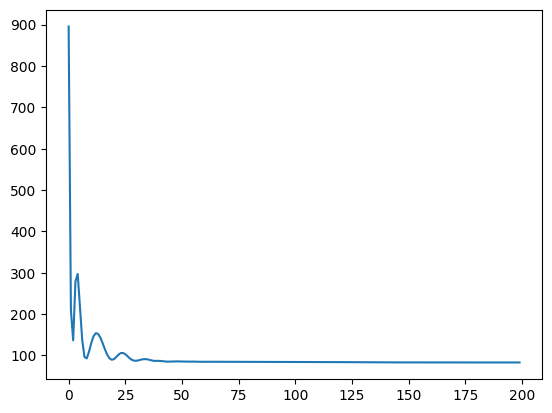

In [13]:
# Plot Losses 
cpu_losses = []

for tensor in losses: 
    loss = tensor.cpu().detach().numpy()
    cpu_losses.append(loss) 

plt.plot(cpu_losses) 

In [14]:
# Evaluated the trained model on the test set 
with torch.no_grad(): 
    y_eval = model.forward(X_test) 
    loss = criterion(y_eval, y_test) 

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([67])) that is different to the input size (torch.Size([67, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [15]:
print(f'Loss: {loss}')

Loss: 91.06399536132812
